In [ ]:
from matplotlib.patches import Ellipse
from matplotlib.collections import PatchCollection
import numpy as np, matplotlib.pyplot as plt


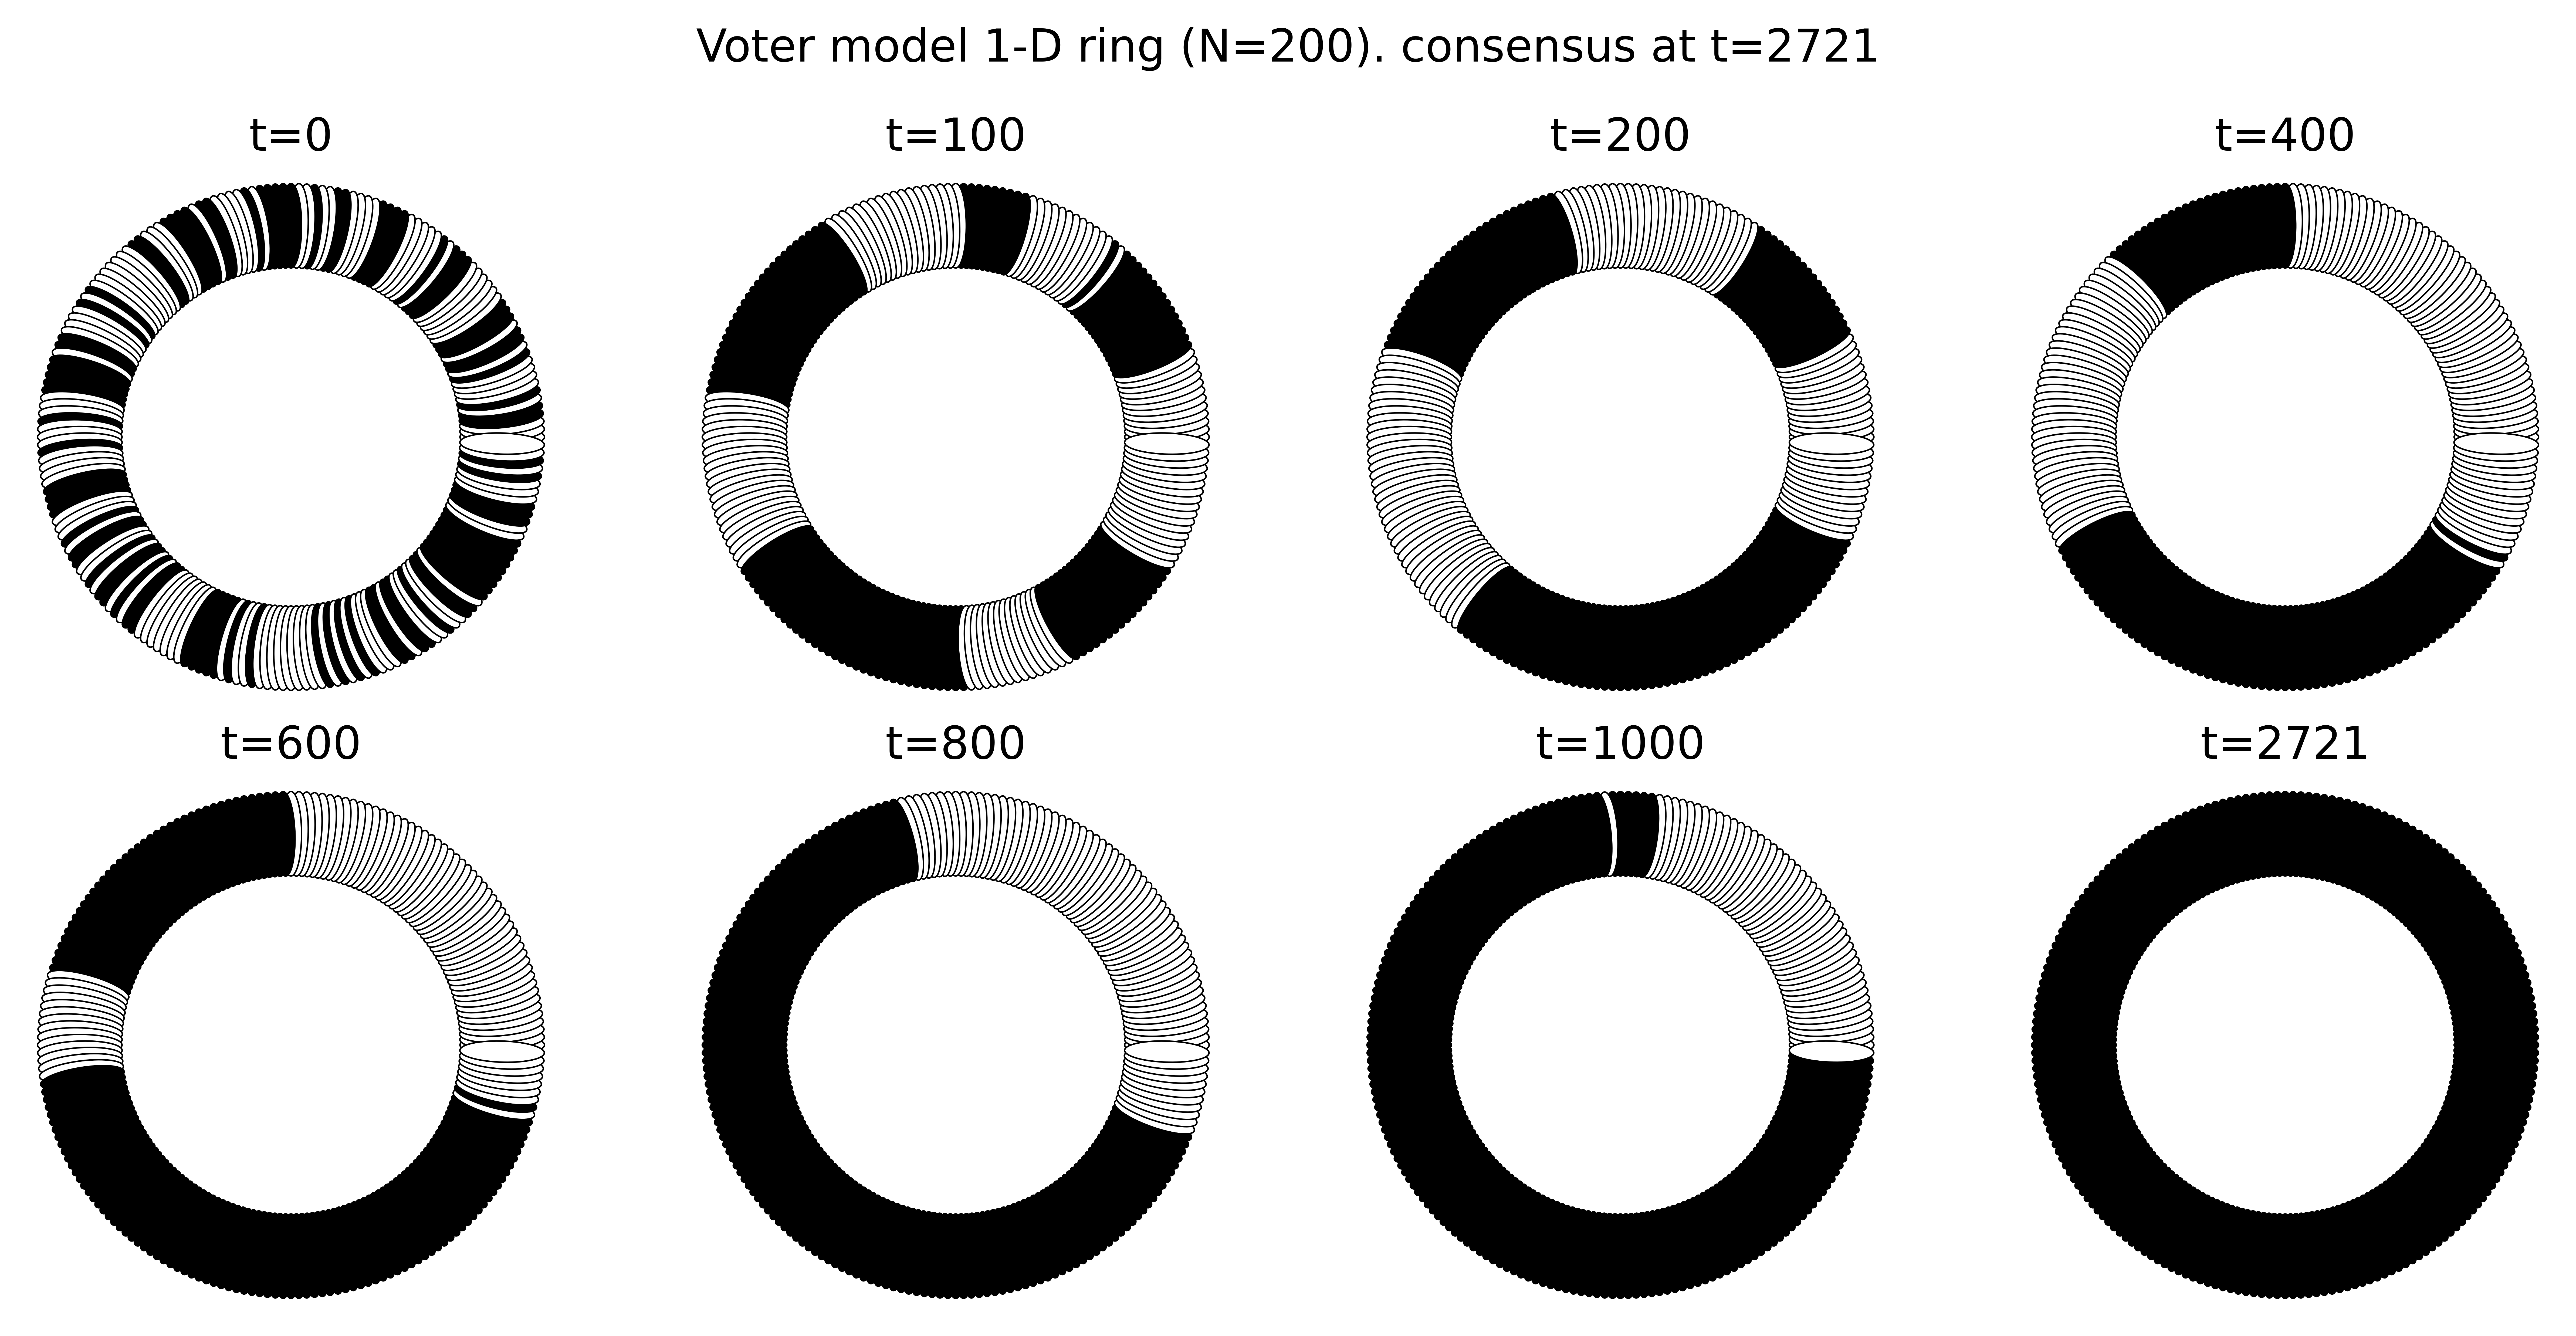

In [ ]:

def voter_ring_with_auto_final(N=200,
                               max_sweeps=12000,
                               snap_list=(0, 100, 200, 400, 600, 800,1000, 8000)):
    """
    Runs a 1‑D voter model on a ring.
    Saves snapshots at all times in snap_list **plus**
    the exact sweep when consensus is reached.
    Returns dict{time: configuration}, consensus_time.
    """
    rng   = np.random.default_rng()
    spins = rng.choice([-1, 1], size=N)

    snapshots = {0: spins.copy()}           # initial state
    target    = set(snap_list) - {0}        # times still to grab

    for sweep in range(1, max_sweeps + 1):
        # asynchronous updates for one sweep
        i  = rng.integers(0, N, size=N)
        nj = (i + rng.choice([-1, 1], size=N)) % N
        spins[i] = spins[nj]

        # save if this sweep is on the list
        if sweep in target:
            snapshots[sweep] = spins.copy()
            target.remove(sweep)

        # check consensus
        if np.all(spins == spins[0]):
            snapshots[sweep] = spins.copy()   # ← final snapshot
            return snapshots, sweep           # done

    # max_sweeps reached without consensus
    snapshots[max_sweeps] = spins.copy()
    return snapshots, max_sweeps

# ---------------- run & plot ----------------
snapshots, T_final = voter_ring_with_auto_final()

# sort times so they appear in order
times = sorted(snapshots.keys())

# 2×4 grid (adjust if you changed snap_list)
fig, axes = plt.subplots(2, 4, figsize=(10, 5), subplot_kw={'aspect': 'equal'},dpi=1000)
for ax, t in zip(axes.flat, times):
    state  = snapshots[t]
    theta  = 2*np.pi*np.arange(len(state))/len(state)
    # ellipse sizes (in data units)
    w = 0.4   # thickness along tangential direction (dθ)
    h = 0.1   # length along radial direction (dr)

    patches = []
    colors = []

    for th, s in zip(theta, state):
        x, y = np.cos(th), np.sin(th)
        angle_deg = np.degrees(th)  # rotate so the long axis points radially
        patches.append(Ellipse((x, y), width=w, height=h, angle=angle_deg))
        colors.append("#FFFFFF" if s == 1 else "#000000")  # or your two colors

    pc = PatchCollection(patches, facecolor=colors, edgecolor="k", linewidth=0.4)
    ax.add_collection(pc)
    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.25)
    ax.set_aspect("equal")

    ax.set_title(f't={t}')
    ax.axis('off')

fig.suptitle(f'Voter model 1-D ring (N=200). consensus at t={T_final}')
plt.tight_layout(); 
plt.savefig("voter_ring_snapshots.png", dpi=500, bbox_inches="tight")
plt.show()



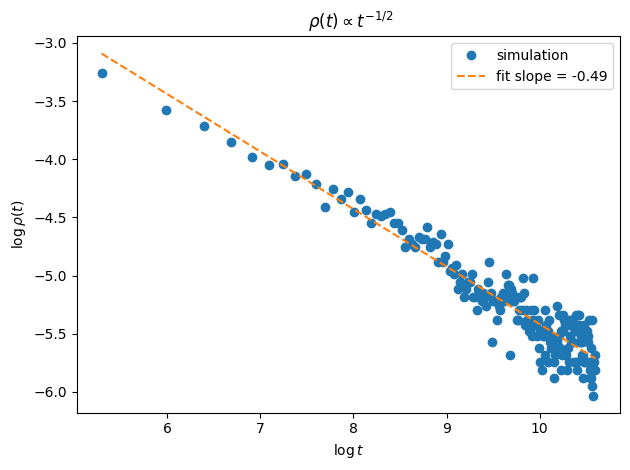

In [ ]:
import numpy as np, matplotlib.pyplot as plt

def voter_ring_once(N=10000, sweeps=40000, step=200):
    rng  = np.random.default_rng()
    spin = rng.choice([-1,1], size=N)
    t, rho = [], []
    for sweep in range(1, sweeps+1):
        idx        = rng.integers(0, N, size=N)
        neighbours = (idx + rng.choice([-1,1], size=N)) % N
        spin[idx]  = spin[neighbours]                    # asynchronous updates
        if sweep % step == 0:
            t.append(sweep)
            rho.append(np.mean(spin != np.roll(spin,-1)))
        if np.all(spin == spin[0]): break               # consensus reached
    return np.array(t), np.array(rho)

t, rho = voter_ring_once()

mask      = rho > 0                      # ignore zeros after consensus
slope, c  = np.polyfit(np.log(t[mask]), np.log(rho[mask]), 1)
fit_line  = np.exp(c) * t**slope
t, rho = voter_ring_once()
mask   = rho > 0                 # ignore zeros after consensus
x, y   = np.log(t[mask]), np.log(rho[mask])
plt.figure()
plt.plot(np.log(t), np.log(rho), 'o', label='simulation')
plt.plot(np.log(t), np.log(fit_line), '--',
         label=fr'fit slope = {slope:.2f}')
plt.xlabel(r'$\log t$');  plt.ylabel(r'$\log \rho(t)$')
plt.title(r' $\rho(t)\propto t^{-1/2}$')
plt.legend(); plt.tight_layout(); plt.show()


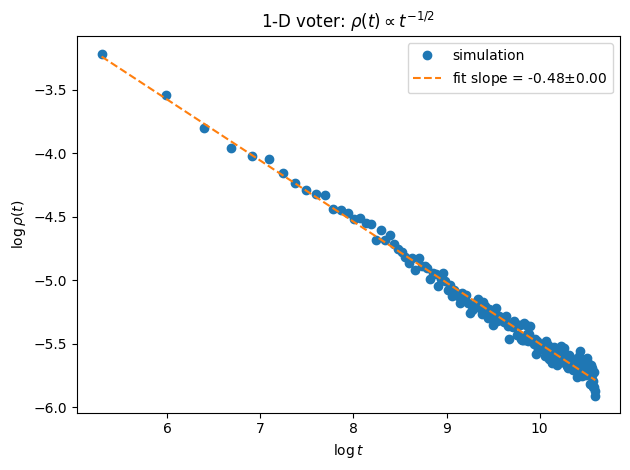

In [18]:
import numpy as np, matplotlib.pyplot as plt

def voter_ring_once(N=100000, sweeps=40000, step=200):
    rng  = np.random.default_rng()
    spin = rng.choice([-1,1], size=N)
    t, rho = [], []
    for sweep in range(1, sweeps+1):
        idx        = rng.integers(0, N, size=N)
        neighbours = (idx + rng.choice([-1,1], size=N)) % N
        spin[idx]  = spin[neighbours]                    # asynchronous updates
        if sweep % step == 0:
            t.append(sweep)
            rho.append(np.mean(spin != np.roll(spin,-1)))
        if np.all(spin == spin[0]): break               # consensus reached
    return np.array(t), np.array(rho)

t, rho = voter_ring_once()
mask   = rho > 0                 # ignore zeros after consensus
x, y   = np.log(t[mask]), np.log(rho[mask])
A      = np.polyfit(x, y, 1)
slope, intercept = A

# --- standard error of the slope -------------
n        = len(x)
y_fit    = slope * x + intercept
residual = y - y_fit
s_var    = np.sum(residual**2) / (n - 2)           # residual variance
x_var    = np.sum((x - x.mean())**2)
slope_err = np.sqrt(s_var / x_var)                 # standard error

# line for plotting
fit_line = np.exp(intercept) * t**slope

# ---------- plot ----------
plt.figure()
plt.plot(np.log(t), np.log(rho), 'o', label='simulation')
plt.plot(np.log(t), np.log(fit_line), '--',
         label=fr'fit slope = {slope:.2f}$\pm${slope_err:.2f}')
plt.xlabel(r'$\log t$')
plt.ylabel(r'$\log \rho(t)$')
plt.title(r'1-D voter: $\rho(t)\propto t^{-1/2}$')
plt.legend(); plt.tight_layout(); plt.show()

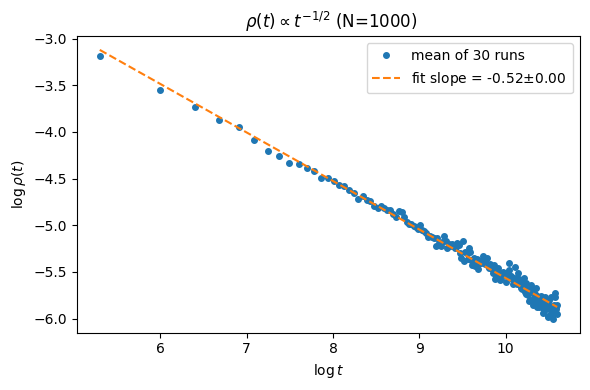

In [ ]:

def voter_ring_once(N=1000, sweeps=40000, step=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    spin = rng.choice([-1, 1], size=N)
    t, rho = [], []
    for sweep in range(1, sweeps + 1):
        idx        = rng.integers(0, N, size=N)
        neighbours = (idx + rng.choice([-1, 1], size=N)) % N
        spin[idx]  = spin[neighbours]
        if sweep % step == 0:
            t.append(sweep)
            rho.append(np.mean(spin != np.roll(spin, -1)))
        if np.all(spin == spin[0]):
            break
    return np.array(t), np.array(rho)

# parameters
N, step, sweeps, runs = 1000, 200, 40000, 100
rng  = np.random.default_rng(0)
time_grid = np.arange(step, sweeps + 1, step)
rho_mat   = np.zeros((runs, len(time_grid)))

for r in range(runs):
    t, rho = voter_ring_once(N=N, sweeps=sweeps, step=step, rng=rng)
    vec = np.zeros_like(time_grid, dtype=float)
    vec[: len(rho)] = rho
    rho_mat[r] = vec

rho_mean = rho_mat.mean(axis=0)
mask     = rho_mean > 0
x, y     = np.log(time_grid[mask]), np.log(rho_mean[mask])

# slope ± error
coef       = np.polyfit(x, y, 1)
slope, intercept = coef
resid      = y - (slope * x + intercept)
s_var      = resid.var(ddof=2)
slope_err  = np.sqrt(s_var / np.sum((x - x.mean())**2))

fit_curve = np.exp(intercept) * time_grid**slope

plt.figure(figsize=(6,4))
plt.plot(x, y, 'o', markersize=4, label='mean of 30 runs')
plt.plot(x, np.log(fit_curve[mask]), '--',
         label=fr'fit slope = {slope:.2f}$\pm${slope_err:.2f} ')
plt.xlabel(r'$\log t$')
plt.ylabel(r'$\log \rho(t)$')
plt.title(r' $\rho(t)\propto t^{-1/2}$ (N=1000)')
plt.legend()
plt.tight_layout()
plt.show()


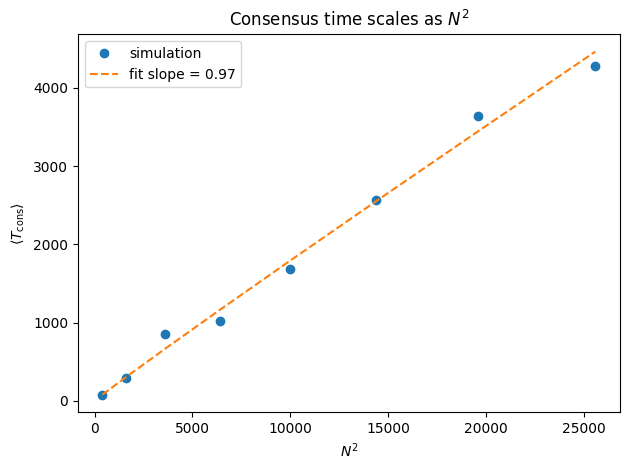

In [ ]:

def consensus_time(N, sweeps=200000):
    rng  = np.random.default_rng()
    spin = rng.choice([-1,1], size=N)
    for sweep in range(1, sweeps+1):
        idx        = rng.integers(0, N, size=N)
        neighbours = (idx + rng.choice([-1,1], size=N)) % N
        spin[idx]  = spin[neighbours]
        if np.all(spin == spin[0]): return sweep
    return sweeps  # max if not converged

sizes = np.array([20, 40,60, 80,100,120,140, 160])
runs  = 15                            # repetitions for each N
Tmean = [np.mean([consensus_time(L) for _ in range(runs)]) for L in sizes]

# fit line in log–log
slope, c = np.polyfit(np.log(sizes**2), np.log(Tmean), 1)
fit = np.exp(c) * (sizes**2)**slope

plt.figure()
plt.plot(sizes**2, Tmean, 'o', label='simulation')
plt.plot(sizes**2, fit, '--', label=fr'fit slope = {slope:.2f}')
plt.xlabel(r'$N^{2}$'); plt.ylabel(r'$\langle T_{\mathrm{cons}}\rangle$')
plt.title(r'Consensus time scales as $N^{2}$')
plt.legend(); plt.tight_layout(); plt.show()


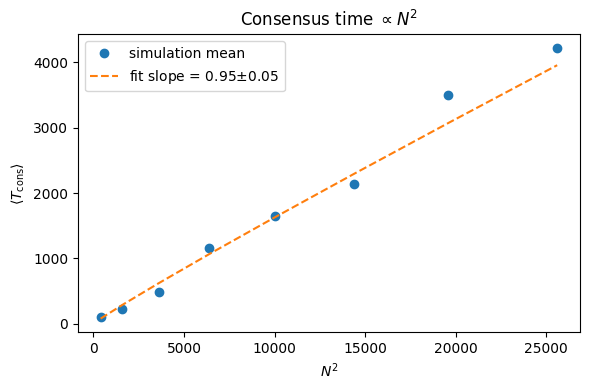

In [ ]:

def consensus_time(N, sweeps=200000, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    spin = rng.choice([-1, 1], size=N)
    for sweep in range(1, sweeps + 1):
        idx        = rng.integers(0, N, size=N)
        neighbours = (idx + rng.choice([-1, 1], size=N)) % N
        spin[idx]  = spin[neighbours]
        if np.all(spin == spin[0]):
            return sweep
    return sweeps  # fallback if not converged

# parameters
sizes = np.array([20, 40, 60, 80, 100, 120, 140, 160])
runs  = 30
rng   = np.random.default_rng(42)

Tmean = [np.mean([consensus_time(L, rng=rng) for _ in range(runs)])
         for L in sizes]

# ----- log–log fit with error -----------------------
x = np.log(sizes**2)
y = np.log(Tmean)
coef = np.polyfit(x, y, 1)
slope, intercept = coef

# standard error of the slope
resid   = y - (slope * x + intercept)
s_var   = resid.var(ddof=2)
x_var   = np.sum((x - x.mean())**2)
slope_err = np.sqrt(s_var / x_var)

fit = np.exp(intercept) * (sizes**2)**slope

# -------------- plot -------------------------------
plt.figure(figsize=(6,4))
plt.plot(sizes**2, Tmean, 'o', label='simulation mean')
plt.plot(sizes**2, fit, '--',
         label=fr'fit slope = {slope:.2f}$\pm${slope_err:.2f}')
plt.xlabel(r'$N^{2}$')
plt.ylabel(r'$\langle T_{\mathrm{cons}}\rangle$')
plt.title(r'Consensus time $\propto N^{2}$')
plt.legend(); plt.tight_layout(); plt.show()
